In [ ]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('/content/datasetCrime.csv', on_bad_lines='skip', engine='python')

print(df.shape)
display(df.head())

(93686, 3)


,category,sub_category,crimeaditionalinfo
0,Online and Social Media Related Crime,Cyber Bullying Stalking Sexting,I had continue received random calls and abusi...
1,Online Financial Fraud,Fraud CallVishing,The above fraudster is continuously messaging ...
2,Online Gambling Betting,Online Gambling Betting,He is acting like a police and demanding for m...
3,Online and Social Media Related Crime,Online Job Fraud,In apna Job I have applied for job interview f...
4,Online Financial Fraud,Fraud CallVishing,I received a call from lady stating that she w...


In [ ]:
df = df.dropna(subset=['crimeaditionalinfo', 'category'])
df = df.drop_duplicates()

print(df.shape)

(85876, 3)


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['crimeaditionalinfo'].apply(clean_text)

df[['crimeaditionalinfo', 'clean_text']].head()

,crimeaditionalinfo,clean_text
0,I had continue received random calls and abusi...,i had continue received random calls and abusi...
1,The above fraudster is continuously messaging ...,the above fraudster is continuously messaging ...
2,He is acting like a police and demanding for m...,he is acting like a police and demanding for m...
3,In apna Job I have applied for job interview f...,in apna job i have applied for job interview f...
4,I received a call from lady stating that she w...,i received a call from lady stating that she w...


In [ ]:
def make_binary_category(cat):
    cat = str(cat).lower()

    if 'financial' in cat or 'fraud' in cat:
        return 'Financial Fraud'
    else:
        return 'Non Financial Cybercrime'

df['binary_category'] = df['category'].apply(make_binary_category)

df['binary_category'].value_counts()

,count
binary_category,
Financial Fraud,52496
Non Financial Cybercrime,33380


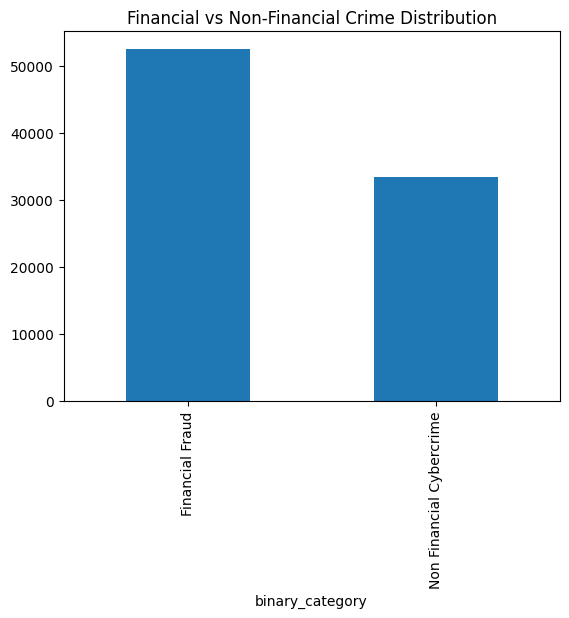

In [ ]:
import matplotlib.pyplot as plt

df['binary_category'].value_counts().plot(
    kind='bar'
)

plt.title("Financial vs Non-Financial Crime Distribution")
plt.show()

In [ ]:
X = df['clean_text']
y = df['binary_category']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(68700,)
(17176,)


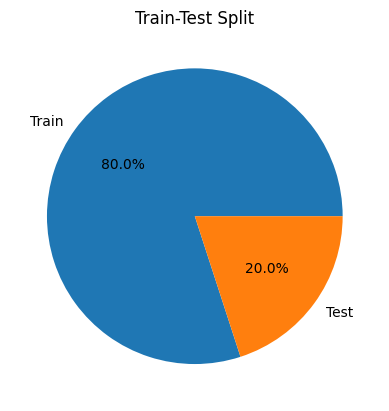

In [ ]:
sizes = [len(X_train), len(X_test)]

plt.pie(
    sizes,
    labels=["Train","Test"],
    autopct="%1.1f%%"
)

plt.title("Train-Test Split")
plt.show()

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=50000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (68700, 50000)
Shape of X_test_tfidf: (17176, 50000)


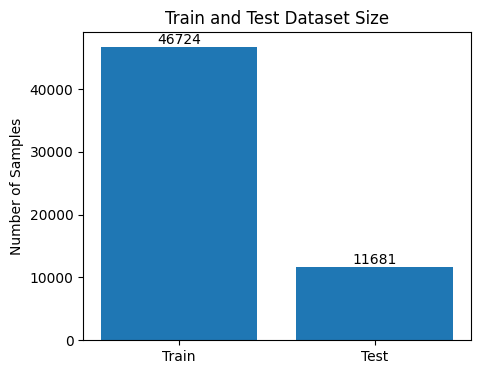

In [ ]:
import matplotlib.pyplot as plt

datasets = ['Train', 'Test']
samples = [46724, 11681]

plt.figure(figsize=(5,4))
plt.bar(datasets, samples)

plt.title("Train and Test Dataset Size")
plt.ylabel("Number of Samples")

for i, v in enumerate(samples):
    plt.text(i, v+500, str(v), ha='center')

plt.show()

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss='modified_huber',
    alpha=1e-5,
    max_iter=5000,
    random_state=42
)

sgd.fit(X_train_tfidf, y_train)

pred = sgd.predict(X_test_tfidf)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8143339543549138
                          precision    recall  f1-score   support

         Financial Fraud       0.84      0.85      0.85     10500
Non Financial Cybercrime       0.77      0.75      0.76      6676

                accuracy                           0.81     17176
               macro avg       0.81      0.80      0.80     17176
            weighted avg       0.81      0.81      0.81     17176



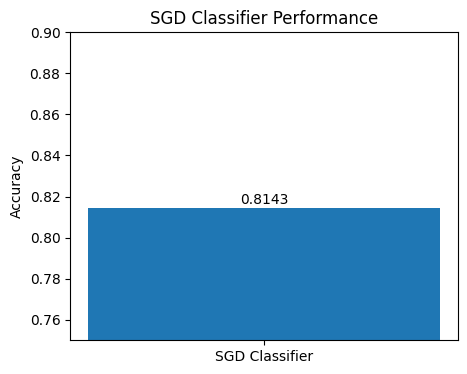

In [ ]:
import matplotlib.pyplot as plt

model = ['SGD Classifier']
accuracy = [0.8143]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("SGD Classifier Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8197484862598975
                          precision    recall  f1-score   support

         Financial Fraud       0.86      0.85      0.85     10500
Non Financial Cybercrime       0.76      0.78      0.77      6676

                accuracy                           0.82     17176
               macro avg       0.81      0.81      0.81     17176
            weighted avg       0.82      0.82      0.82     17176



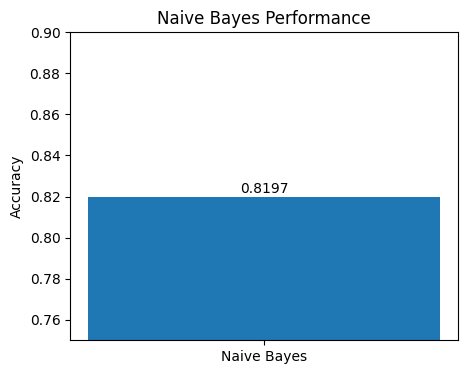

In [ ]:
import matplotlib.pyplot as plt

model = ['Naive Bayes']
accuracy = [0.8197]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Naive Bayes Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=5000,
    solver='saga',
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8235328365160689
                          precision    recall  f1-score   support

         Financial Fraud       0.89      0.81      0.85     10500
Non Financial Cybercrime       0.74      0.84      0.79      6676

                accuracy                           0.82     17176
               macro avg       0.81      0.83      0.82     17176
            weighted avg       0.83      0.82      0.83     17176



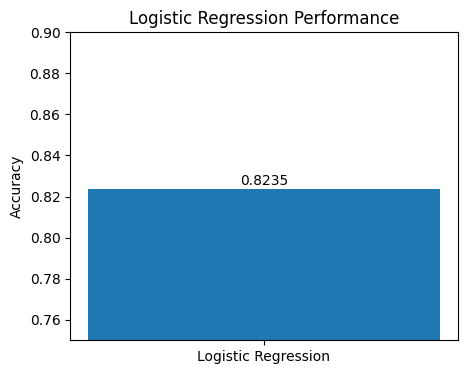

In [ ]:
import matplotlib.pyplot as plt

model = ['Logistic Regression']
accuracy = [0.8235]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Logistic Regression Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

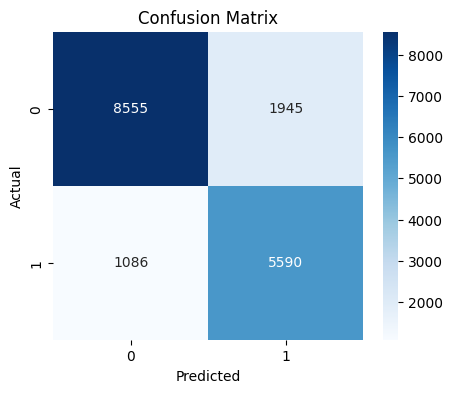

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight='balanced',
    C=1,
    max_iter=5000
)

svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8183511877037727
                          precision    recall  f1-score   support

         Financial Fraud       0.87      0.83      0.85     10500
Non Financial Cybercrime       0.75      0.81      0.78      6676

                accuracy                           0.82     17176
               macro avg       0.81      0.82      0.81     17176
            weighted avg       0.82      0.82      0.82     17176



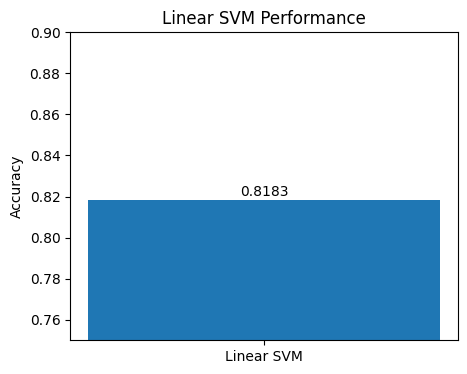

In [ ]:
import matplotlib.pyplot as plt

model = ['Linear SVM']
accuracy = [0.8183]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Linear SVM Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

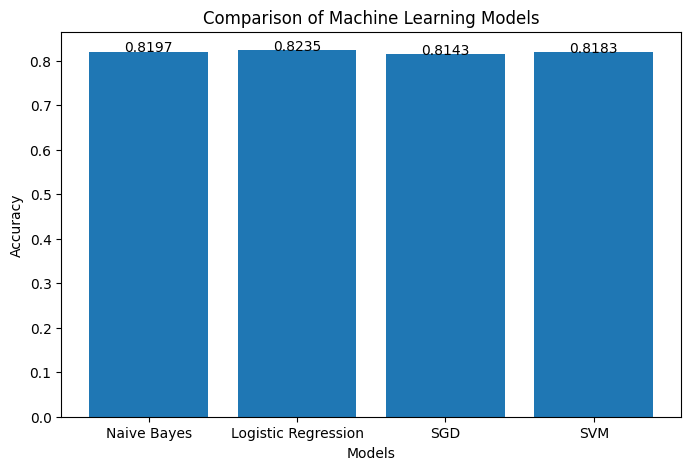

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Naive Bayes',
    'Logistic Regression',
    'SGD',
    'SVM'
]

scores = [
    0.8197,
    0.8235,
    0.8143,
    0.8183
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Comparison of Machine Learning Models")

for i, v in enumerate(scores):
    plt.text(i, v+0.0003,
             f"{v:.4f}",
             ha='center')

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_test, lr_pred))

                          precision    recall  f1-score   support

         Financial Fraud       0.89      0.81      0.85     10500
Non Financial Cybercrime       0.74      0.84      0.79      6676

                accuracy                           0.82     17176
               macro avg       0.81      0.83      0.82     17176
            weighted avg       0.83      0.82      0.83     17176

